In [3]:
import random, os, re, multiprocessing, nltk, gc
from tabulate import tabulate
from tqdm import tqdm
import time

# Processing & Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, 
    accuracy_score, 
    confusion_matrix,
    mean_absolute_error, 
    mean_absolute_percentage_error
)
from sklearn.model_selection import train_test_split
from collections import Counter
from wordcloud import WordCloud

# Modelling
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, Bidirectional, Embedding, SpatialDropout1D
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.utils import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.regularizers import l2

In [4]:
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [5]:
df = pd.read_csv('dataset.csv', header=0)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   sumber  5008 non-null   object
 1   text    5008 non-null   object
 2   label   5008 non-null   object
dtypes: object(3)
memory usage: 117.5+ KB
None


In [24]:
df

,sumber,text,label
0,jurnal,Perkembangan teknologi informasi saat ini menj...,human
1,jurnal,Perkembangan teknologi informasi mendorong pen...,human
2,jurnal,Produksi perikanan tangkap merupakan sektor st...,human
3,jurnal,Keamanan data merupakan aspek prioritas dalam ...,human
4,jurnal,Manajemen produk BBM subsidi dan non-subsidi d...,human
...,...,...,...
5003,jurnal,", UD. Global Solution Computer merupakan perus...",ai
5004,jurnal,", Pengelolaan sampah merupakan isu global yang...",ai
5005,jurnal,", Kelulusan tepat waktu merupakan salah satu s...",ai
5006,jurnal,", Metode Case-Based Reasoning atau CBR merupak...",ai


In [6]:
def text_preprocessing(text):
    # 1. cleaning
    text = text.replace('-', ' ')
    text = re.sub(r'[\r\xa0\t]', '', text)
    text = re.sub(r"http\S+|www\S+", '', text)
    text = re.sub(r'\b\w*\.com\w*\b', '', text)
    text = re.sub(r'\[.*?\]|\(.*?\}|\{.*?\}', '', text)
    text = re.sub(r'\b(\w+)/(\w+)\b', r'\1 atau \2', text)
    text = re.sub(r'@[A-Za-z0-9]+|#[A-Za-z0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.replace('\n', ' ')
    text = text.strip(' ')
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # 2. case folding
    text = text.lower()
    return text

def data_preprocessing(data):
    data['text'] = data['text'].apply(lambda _: text_preprocessing(str(_)))
    return data

def clean_memory():
    gc.collect()
    tf.keras.backend.clear_session()

In [25]:
data

,sumber,text,label
0,jurnal,dalam proses budidaya lele ada beberapa faktor...,human
1,jurnal,kemajuan teknologi di dunia medis mempermudah ...,human
2,jurnal,analisis mengenai kinerja jaringan internet di...,human
3,jurnal,penelitian ini bertujuan untuk membangun suatu...,human
4,jurnal,penelitian ini dilakukan untuk memberikan reko...,human
...,...,...,...
5003,jurnal,shopee merupakan tempat transaksi perdagangan ...,human
5004,jurnal,penyaluran bantuan dana kepada masyarakat kura...,ai
5005,jurnal,kulit merupakan organ tubuh terluar yang memba...,ai
5006,jurnal,pt sari segar husada merupakan perusahaan yang...,ai


In [7]:
data = df.copy()
data = data_preprocessing(data)

# Handling empty string
data = data[data['text'].str.len() > 0]
data.reset_index(drop=True, inplace=True)
print(f'Shape after cleaning: {data.shape}')

Shape after cleaning: (5008, 3)



=== DISTRIBUSI KELAS ===
label
human    2513
ai       2495
Name: count, dtype: int64
------------------------------


C:\Users\Rafil\AppData\Local\Temp\ipykernel_17980\23058710.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=data, palette='rocket')


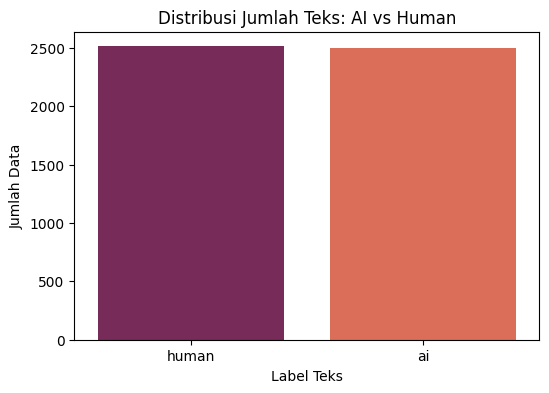

In [8]:
print("\n=== DISTRIBUSI KELAS ===")
class_counts = data['label'].value_counts()
print(class_counts)
print("-" * 30)

plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=data, palette='rocket')
plt.title('Distribusi Jumlah Teks: AI vs Human')
plt.xlabel('Label Teks')
plt.ylabel('Jumlah Data')
plt.show()


=== STATISTIK PANJANG KATA BERDASARKAN KELAS ===
        count        mean        std   min    25%    50%    75%    max
label                                                                 
ai     2495.0  181.660922  61.041440  17.0  148.0  176.0  201.5  713.0
human  2513.0  181.688818  64.726798  17.0  147.0  174.0  199.0  733.0
--------------------------------------------------


C:\Users\Rafil\AppData\Local\Temp\ipykernel_17980\1940547191.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='label', y='word_count', palette='rocket')


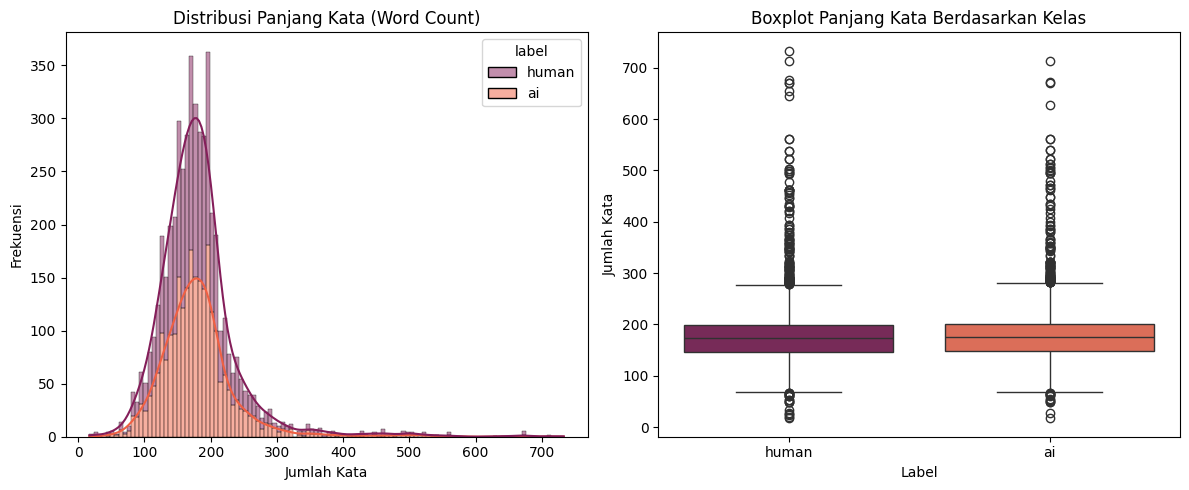

In [9]:
data['word_count'] = data['text'].apply(lambda x: len(x.split()))
data['char_count'] = data['text'].apply(lambda x: len(x))

print("\n=== STATISTIK PANJANG KATA BERDASARKAN KELAS ===")
print(data.groupby('label')['word_count'].describe())
print("-" * 50)

plt.figure(figsize=(12, 5))

# Histogram Distribusi Panjang Kata
plt.subplot(1, 2, 1)
sns.histplot(data=data, x='word_count', hue='label', kde=True, palette='rocket', multiple='stack')
plt.title('Distribusi Panjang Kata (Word Count)')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')

# Boxplot Panjang Kata
plt.subplot(1, 2, 2)
sns.boxplot(data=data, x='label', y='word_count', palette='rocket')
plt.title('Boxplot Panjang Kata Berdasarkan Kelas')
plt.xlabel('Label')
plt.ylabel('Jumlah Kata')

plt.tight_layout()
plt.show()

C:\Users\Rafil\AppData\Local\Temp\ipykernel_17980\4016384865.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Kata', data=df_ai_words, palette='magma')
C:\Users\Rafil\AppData\Local\Temp\ipykernel_17980\4016384865.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Kata', data=df_human_words, palette='viridis')


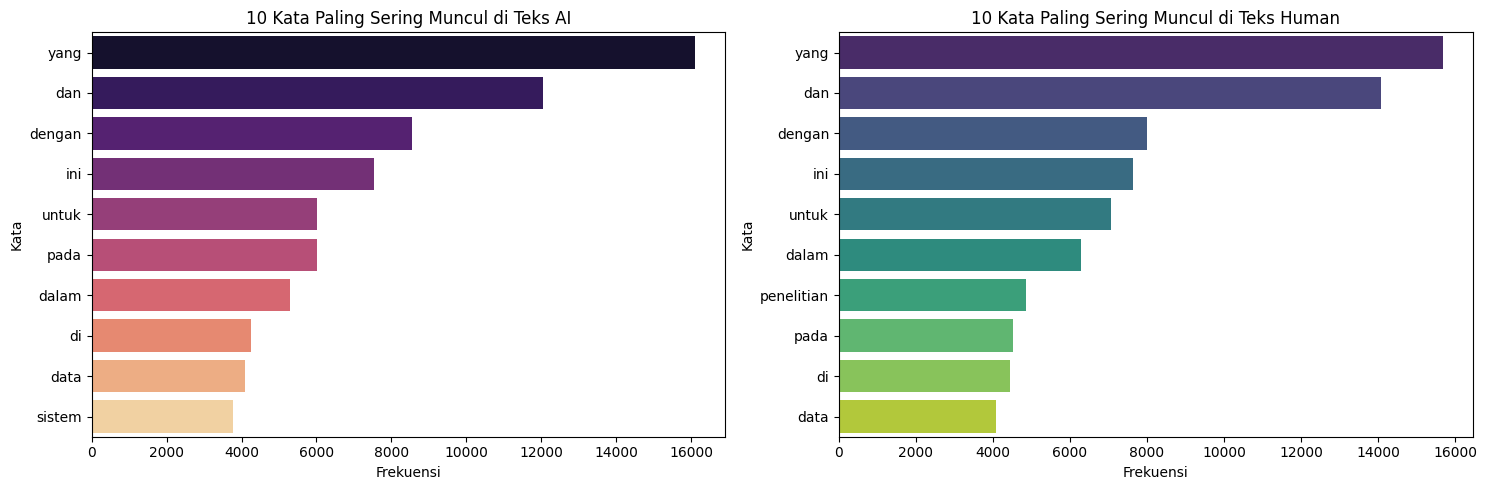

In [10]:
def get_top_ngram(corpus, top_n=10):
    words = [word for text in corpus for word in text.split()]
    words_counts = Counter(words)
    return words_counts.most_common(top_n)

ai_corpus = data[data['label'] == 'ai']['text']
human_corpus = data[data['label'] == 'human']['text']

top_ai_words = get_top_ngram(ai_corpus, top_n=10)
top_human_words = get_top_ngram(human_corpus, top_n=10)

df_ai_words = pd.DataFrame(top_ai_words, columns=['Kata', 'Frekuensi'])
df_human_words = pd.DataFrame(top_human_words, columns=['Kata', 'Frekuensi'])

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.barplot(x='Frekuensi', y='Kata', data=df_ai_words, palette='magma')
plt.title('10 Kata Paling Sering Muncul di Teks AI')

plt.subplot(1, 2, 2)
sns.barplot(x='Frekuensi', y='Kata', data=df_human_words, palette='viridis')
plt.title('10 Kata Paling Sering Muncul di Teks Human')

plt.tight_layout()
plt.show()

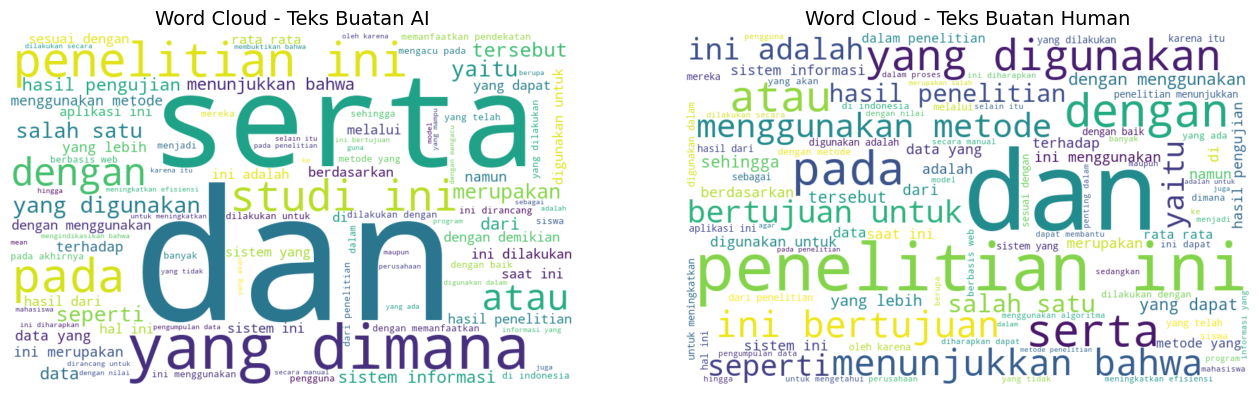

In [11]:
ai_text = " ".join(review for review in data[data['label'] == 'ai']['text'])
human_text = " ".join(review for review in data[data['label'] == 'human']['text'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Wordcloud AI
wordcloud_ai = WordCloud(width=800, height=500, background_color='white', max_words=100).generate(ai_text)
ax1.imshow(wordcloud_ai, interpolation='bilinear')
ax1.set_title('Word Cloud - Teks Buatan AI', fontsize=14)
ax1.axis('off')

# Wordcloud Human
wordcloud_human = WordCloud(width=800, height=500, background_color='white', max_words=100).generate(human_text)
ax2.imshow(wordcloud_human, interpolation='bilinear')
ax2.set_title('Word Cloud - Teks Buatan Human', fontsize=14)
ax2.axis('off')

plt.show()

In [12]:
data = data.drop(columns=['word_count', 'char_count'])

data = data.sample(frac=1, random_state=42).reset_index(drop=True)

X = data['text']
y = data['label'].map({'ai': 1, 'human': 0}).values

# Split menjadi Train (70%) dan Validation (30%)
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.7, stratify=y, random_state=seed)

print(f'X_train shape:  {X_train.shape}')
print(f'X_val shape:    {X_val.shape}')

X_train shape:  (3505,)
X_val shape:    (1503,)


In [13]:
MAX_WORDS = 15000  
MAX_LEN = 200      

# Inisialisasi Keras Tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Mengubah teks menjadi sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

# Padding
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')

In [15]:
clean_memory()

model = Sequential(name='Optimized_Bi_LSTM')

# 1. Embedding Layer
model.add(Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN))
model.add(SpatialDropout1D(0.4)) 

# 2. Layer Bi-LSTM dengan L2 Regularization
model.add(Bidirectional(LSTM(
    32, 
    kernel_regularizer=l2(0.001), 
    recurrent_regularizer=l2(0.001)
)))
model.add(Dropout(0.4)) 

# 3. Dense Layer
model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

# Paksa kalkulasi arsitektur bentuk input
model.build(input_shape=(None, MAX_LEN))

# Compile Model
model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\Rafil\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Optimized_Bi_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 200, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 985,889 (3.76 MB)

 Trainable params: 985,889 (3.76 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model_bilstm.keras', monitor='val_loss', save_best_only=True, mode='min', verbose=1)

start_time = time.time()
history = model.fit(
    X_train_pad, y_train, 
    validation_data=(X_val_pad, y_val), 
    epochs=15,          
    batch_size=64,      
    callbacks=[early_stop, checkpoint],
    verbose=1
)
print(f"Lama Waktu Training: {time.time() - start_time:.2f} detik")

# Memuat model terbaik
best_model = tf.keras.models.load_model("best_model_bilstm.keras")

Epoch 1/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5003 - loss: 0.9268
Epoch 1: val_loss improved from None to 0.86080, saving model to best_model_bilstm.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.5084 - loss: 0.9044 - val_accuracy: 0.5409 - val_loss: 0.8608
Epoch 2/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5590 - loss: 0.8435
Epoch 2: val_loss improved from 0.86080 to 0.80169, saving model to best_model_bilstm.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.5478 - loss: 0.8293 - val_accuracy: 0.5269 - val_loss: 0.8017
Epoch 3/15
54/55 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5850 - loss: 0.7891
Epoch 3: val_loss improved from 0.80169 to 0.75799, saving model to best_model_bilstm.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5857 - loss: 0.7779 - val_accuracy: 0.5882 - val_loss: 0.7580
Epoch 4/15
54/55 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7049 - loss: 0.6825
Epoch 4: val_loss improved from 0.75799

In [20]:
y_pred_prob = best_model.predict(X_val_pad)
y_pred_prob = y_pred_prob.flatten()
y_pred = np.round(y_pred_prob)

print("\n--- Classification Report ---")
print(classification_report(y_val, y_pred))

# Menghitung MAE dan MAPE berdasarkan nilai probabilitas mentah
mae_value = mean_absolute_error(y_val, y_pred_prob)

print("--- Tambahan Metrik Evaluasi ---")
print(f"Mean Absolute Error (MAE)            : {mae_value:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.72      0.94      0.81       754
           1       0.91      0.63      0.74       749

    accuracy                           0.78      1503
   macro avg       0.81      0.78      0.78      1503
weighted avg       0.81      0.78      0.78      1503

--- Tambahan Metrik Evaluasi ---
Mean Absolute Error (MAE)            : 0.3295


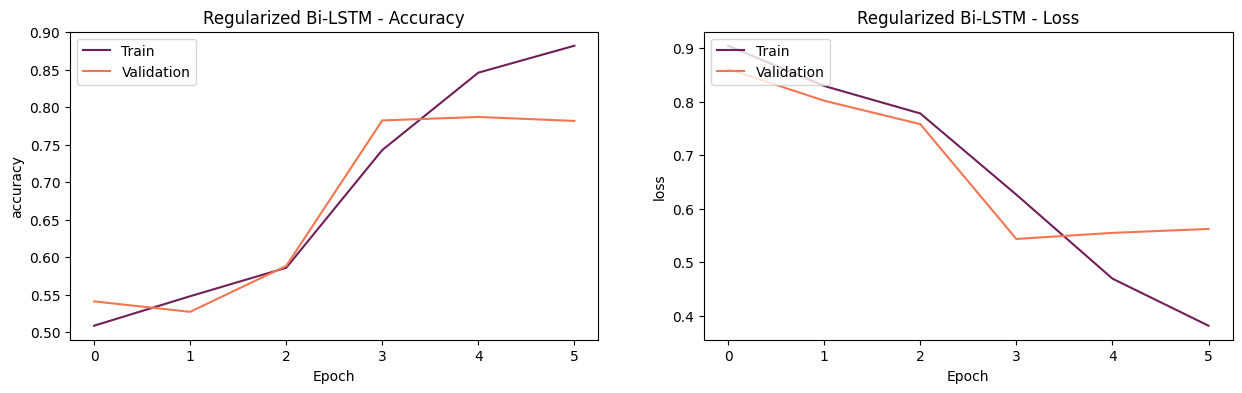

In [21]:
plt.figure(figsize=(15, 4))
metrics_plot = ['accuracy', 'loss']

for i, metric in enumerate(metrics_plot):
    plt.subplot(1, 2, i+1)
    plt.plot(history.history[metric], color=sns.color_palette('rocket')[1], label='Train')
    plt.plot(history.history[f'val_{metric}'], color=sns.color_palette('rocket')[4], label='Validation')
    plt.title(f'Regularized Bi-LSTM - {metric.capitalize()}')
    plt.ylabel(metric)
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

plt.show()

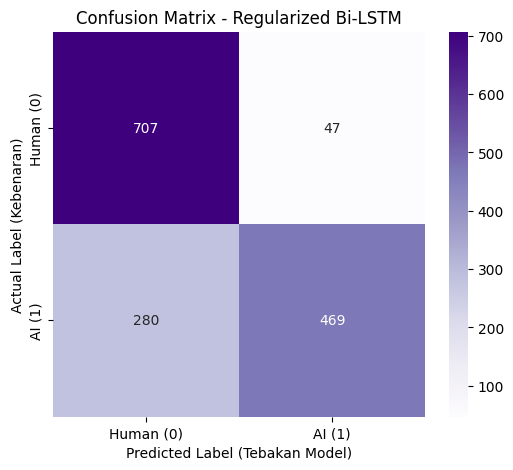

In [22]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Purples', 
    xticklabels=['Human (0)', 'AI (1)'], 
    yticklabels=['Human (0)', 'AI (1)']
)

plt.title('Confusion Matrix - Regularized Bi-LSTM')
plt.ylabel('Actual Label (Kebenaran)')
plt.xlabel('Predicted Label (Tebakan Model)')
plt.show()

In [ ]:
import json
import pickle

# 1. Simpan Keras Tokenizer agar indeks kata tidak berubah saat dideploy
tokenizer_json = tokenizer.to_json()
with open("tokenizer.json", "w") as json_file:
    json_file.write(tokenizer_json)

# 2. Simpan Arsitektur dan Weight Model Bi-LSTM Anda
model.save("model_bilstm.keras")

print("Model dan Tokenizer berhasil disimpan!")import json
import pickle

# 1. Simpan Keras Tokenizer agar indeks kata tidak berubah saat dideploy
tokenizer_json = tokenizer.to_json()
with open("tokenizer.json", "w") as json_file:
    json_file.write(tokenizer_json)

# 2. Simpan Arsitektur dan Weight Model Bi-LSTM Anda
model.save("model_bilstm.keras")

print("Model dan Tokenizer berhasil disimpan!")